In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_pickle(
    "data/coursera_cleaned.pkl"
)

In [3]:
df.sample(5)

,Course Title,Rating,Level,What you will learn,Skill gain,Modules,Instructor,Offered By,Course Url,Keyword,duration_hours,review_count,skills_text,keywords_text,instructors_text,institution_text,content_soup
646,Beer Quality: Freshness,4.7,Intermediate level,"Discover the science behind beer freshness, ho...",[],"[Getting Started & Beer Freshness, The Science...",[Charles Bamforth],"[University of California, Davis]",https://www.coursera.org/learn/beer-quality-fr...,[Physical Science and Engineering],7,0,,Physical Science and Engineering,Charles Bamforth,"University of California, Davis",Beer Quality: Freshness Discover the science b...
3392,Introduction to Android Mobile Application Dev...,4.6,Beginner level,Define the Fundamental concepts of Android app...,"[Android Studio, Application development, Mobi...",[Introduction to Mobile Application Developmen...,[Taught by Meta Staff],[Meta],https://www.coursera.org/learn/introduction-to...,[Computer Science],11,1011,Android Studio Application development Mobile ...,Computer Science,Taught by Meta Staff,Meta,Introduction to Android Mobile Application Dev...
2273,Exploratory Data Analysis With Python and Pandas,4.5,Beginner level,Apply practical Exploratory Data Analysis (EDA...,"[Data Analysis, Python Programming, Pandas, Ex...",[Learn step-by-step],[Bassim Eledath ],[Coursera Project Network],https://www.coursera.org/projects/exploratory-...,[DataScience],2,395,Data Analysis Python Programming Pandas Explor...,DataScience,Bassim Eledath,Coursera Project Network,Exploratory Data Analysis With Python and Pand...
1885,Diseño Instruccional: Aprendizaje activo y Ped...,4.7,Beginner level,Aplicar bases teóricas que sustenten un pensam...,"[Análisis, Pensamiento crítico, Comunicación e...",[Diseño instruccional para el aprendizaje acti...,"[Marcela Georgina Gomez Zermeño, María Soledad...",[Tecnológico de Monterrey],https://www.coursera.org/specializations/disen...,[Social Sciences],120,714,Análisis Pensamiento crítico Comunicación efec...,Social Sciences,Marcela Georgina Gomez Zermeño María Soledad R...,Tecnológico de Monterrey,Diseño Instruccional: Aprendizaje activo y Ped...
736,"Build Regression, Classification, and Clusteri...",4.2,Intermediate level,Train and evaluate linear regression models.Tr...,"[Linear Regression, Machine Learning (ML) Algo...",[Build Linear Regression Models Using Linear A...,[Anastas Stoyanovsky],[CertNexus],https://www.coursera.org/learn/build-regressio...,[Math and Logic],20,10,Linear Regression Machine Learning (ML) Algori...,Math and Logic,Anastas Stoyanovsky,CertNexus,"Build Regression, Classification, and Clusteri..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6404 entries, 0 to 6403
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Course Title         6404 non-null   object 
 1   Rating               6404 non-null   float64
 2   Level                6404 non-null   object 
 3   What you will learn  6404 non-null   object 
 4   Skill gain           6404 non-null   object 
 5   Modules              6404 non-null   object 
 6   Instructor           6404 non-null   object 
 7   Offered By           6404 non-null   object 
 8   Course Url           6404 non-null   object 
 9   Keyword              6404 non-null   object 
 10  duration_hours       6404 non-null   int64  
 11  review_count         6404 non-null   int64  
 12  skills_text          6404 non-null   object 
 13  keywords_text        6404 non-null   object 
 14  instructors_text     6404 non-null   object 
 15  institution_text     6404 non-null   o

In [5]:
df['content_soup'][0]

' Assisting Public Sector Decision Makers With Policy Analysis Apply data analysis techniques to the core public sector principles of efficiency, effectiveness, and equityDevelop analytical skills commonly used to analyze and assess policies and programsAnswer questions policymakers ask such as “What should we do?” and “Did it work?”  Policy Analysis Data Analysis Policy/Program evalaution R Programming Social Sciences Paula Lantz Christopher Brooks University of Michigan Intermediate level'

# TF-IDF Vectorization

The content_soup representation is transformed into numerical vectors using TF-IDF.

TF-IDF assigns higher importance to distinctive terms while reducing the influence of very common words.

In [6]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf.fit_transform(
    df['content_soup']
)

10000 is vocabulary size

In [7]:
tfidf_matrix.shape

(6404, 10000)

# Cosine Similarity

Cosine similarity is used to measure the similarity between course vectors.

Higher similarity values indicate stronger content overlap.

In [8]:
cosine_sim = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

In [9]:
cosine_sim.shape

(6404, 6404)

In [10]:
indices = pd.Series(
    df.index,
    index=df['Course Title']
).drop_duplicates()

In [11]:
indices.head()

Course Title
Assisting Public Sector Decision Makers With Policy Analysis                                                          0
Atención prehospitalaria del ictus agudo y selección de pacientes para tratamiento endovascular con la escala RACE    1
Build a social media presence for your business using Canva                                                           2
Build social awareness content for Twitter with Canva                                                                 3
Comercio, Inmigración y Tipos de Cambio en un Mundo Globalizado                                                       4
dtype: int64

In [12]:
def recommend_courses(course_title, top_n=10):

    if course_title not in indices:
        return f"Course '{course_title}' not found."

    idx = indices[course_title]

    sim_scores = list(
        enumerate(cosine_sim[idx])
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:top_n+1]

    course_indices = [
        i[0]
        for i in sim_scores
    ]

    return df[
        [
            'Course Title',
            'Rating',
            'Level',
            'Keyword'
        ]
    ].iloc[course_indices]

In [13]:
df['Course Title'].sample(5)

6127                            Working as a Scrum Master
3395       Introduction to Architecting Smart IoT Devices
1465    Custom Models, Layers, and Loss Functions with...
1737    Design and Make Infographics (Project-Centered...
1770                    DevOps on AWS: Release and Deploy
Name: Course Title, dtype: object

In [14]:
recommend_courses(
    "Generative AI: Foundation Models and Platforms"
)

,Course Title,Rating,Level,Keyword
2613,Generative AI Fundamentals Specialization,4.7,Beginner level,"[DataScience, Computer Science]"
2627,Generative AI: Introduction and Applications,4.7,Beginner level,"[DataScience, Computer Science]"
2617,Generative AI for Everyone,4.9,Beginner level,[DataScience]
2626,"Generative AI: Impact, Considerations, and Eth...",4.7,Beginner level,[DataScience]
2612,Generative AI Essentials: Overview and Impact,4.7,Beginner level,"[DataScience, Math and Logic]"
3512,Introduction to Generative AI,4.6,Beginner level,[Information Technology]
3511,Introduction to Generative AI,3.9,Intermediate level,[Computer Science]
2616,Generative AI for Data Scientists Specialization,4.8,Intermediate level,"[DataScience, Computer Science]"
2624,Generative AI: Business Transformation and Car...,4.7,Beginner level,[Business]
2619,Generative AI for Software Developers Speciali...,5.0,Intermediate level,[Computer Science]


# Baseline Recommendation Model

A popularity-based baseline is created using a Bayesian weighted rating.

Using raw ratings alone can be misleading because courses with very few reviews may appear highly ranked.

The weighted score combines:

- Course Rating
- Number of Reviews

This produces a more reliable ranking of globally popular courses.

In [15]:
C = df['Rating'].mean()

print("Global Mean Rating:", round(C, 3))

Global Mean Rating: 4.655


In [16]:
m = df['review_count'].quantile(0.25)

print("Review Threshold:", m)

Review Threshold: 16.0


In [17]:
df['weighted_score'] = (
    (
        df['review_count']
        /
        (df['review_count'] + m)
    )
    *
    df['Rating']
    +
    (
        m
        /
        (df['review_count'] + m)
    )
    *
    C
)

In [18]:
baseline_top10 = (
    df[
        [
            'Course Title',
            'Rating',
            'review_count',
            'weighted_score'
        ]
    ]
    .sort_values(
        'weighted_score',
        ascending=False
    )
    .head(10)
)

baseline_top10

,Course Title,Rating,review_count,weighted_score
3758,Keamanan IT: Pertahanan terhadap Kejahatan Dig...,5.0,1148,4.995260
4072,Manajemen Proyek Google Professional Certificate,5.0,369,4.985671
1172,Compreendendo o Zika e doenças emergentes,5.0,243,4.978700
5899,Uncommon Sense Teaching Specialization,5.0,164,4.969351
2283,Exploring Beethoven’s Piano Sonatas Part 2,5.0,161,4.968832
4170,Medical Terminology II,5.0,90,4.947955
1886,Diseño de Actividades con PhET para la Educaci...,5.0,71,4.936588
2152,Escola 4.0 Educação e Cultura Maker no Context...,5.0,48,4.913800
6375,莊子─人情 (Zhuangzi─Between People),5.0,45,4.909561
2280,Exploring Beethoven's Piano Sonatas Part 5,5.0,45,4.909561


In [19]:
top10_plot = (
    df[
        [
            'Course Title',
            'weighted_score'
        ]
    ]
    .sort_values(
        'weighted_score',
        ascending=False
    )
    .head(10)
    .sort_values(
        'weighted_score'
    )
)

top10_plot

,Course Title,weighted_score
2280,Exploring Beethoven's Piano Sonatas Part 5,4.909561
6375,莊子─人情 (Zhuangzi─Between People),4.909561
2152,Escola 4.0 Educação e Cultura Maker no Context...,4.913800
1886,Diseño de Actividades con PhET para la Educaci...,4.936588
4170,Medical Terminology II,4.947955
2283,Exploring Beethoven’s Piano Sonatas Part 2,4.968832
5899,Uncommon Sense Teaching Specialization,4.969351
1172,Compreendendo o Zika e doenças emergentes,4.978700
4072,Manajemen Proyek Google Professional Certificate,4.985671
3758,Keamanan IT: Pertahanan terhadap Kejahatan Dig...,4.995260


C:\Users\Purav Shah\AppData\Local\Temp\ipykernel_17944\2929021905.py:11: UserWarning: Glyph 33674 (\N{CJK UNIFIED IDEOGRAPH-838A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Purav Shah\AppData\Local\Temp\ipykernel_17944\2929021905.py:11: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Purav Shah\AppData\Local\Temp\ipykernel_17944\2929021905.py:11: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Purav Shah\AppData\Local\Temp\ipykernel_17944\2929021905.py:11: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Purav Shah\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33674 (\N{CJK UNIFIED IDEOGRAPH-838A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Purav Shah\App

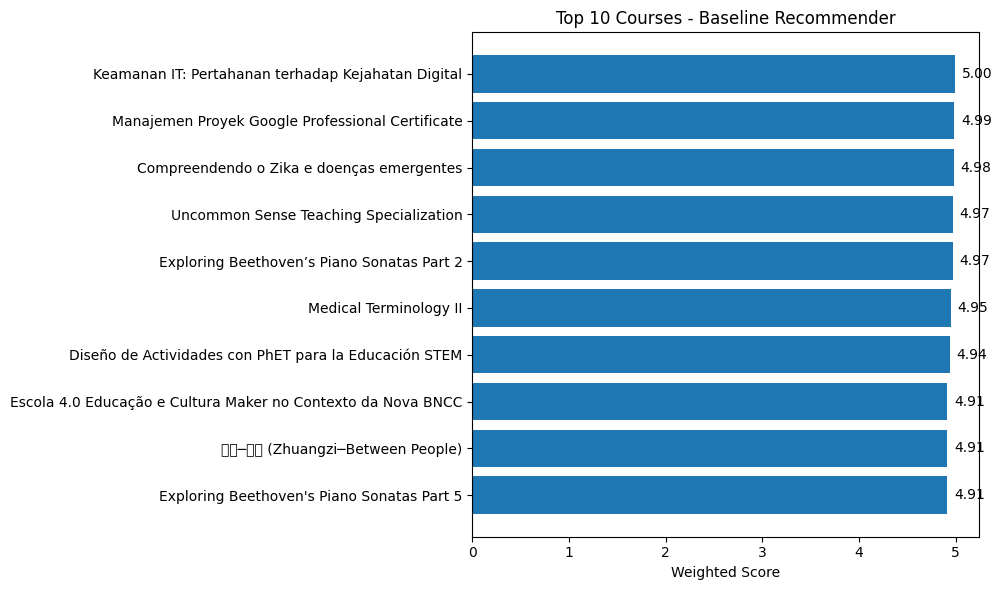

In [20]:
plt.figure(figsize=(10,6))

bars = plt.barh(top10_plot['Course Title'], top10_plot['weighted_score'])

# Add numerical values as labels on the bars (e.g., formatting to 2 decimal places)
plt.bar_label(bars, fmt='%.2f', padding=5)

plt.title("Top 10 Courses - Baseline Recommender")
plt.xlabel("Weighted Score")

plt.tight_layout()
plt.show()

# Baseline Recommendation Function

The baseline recommender returns the globally highest-ranked courses based on weighted ratings.

Unlike the content-based model, recommendations are identical for every user and do not depend on course similarity.

In [21]:
def baseline_recommend(top_n=10):

    return (
        df[
            [
                'Course Title',
                'Rating',
                'review_count',
                'weighted_score'
            ]
        ]
        .sort_values(
            'weighted_score',
            ascending=False
        )
        .head(top_n)
    )

In [22]:
baseline_recommend()

,Course Title,Rating,review_count,weighted_score
3758,Keamanan IT: Pertahanan terhadap Kejahatan Dig...,5.0,1148,4.995260
4072,Manajemen Proyek Google Professional Certificate,5.0,369,4.985671
1172,Compreendendo o Zika e doenças emergentes,5.0,243,4.978700
5899,Uncommon Sense Teaching Specialization,5.0,164,4.969351
2283,Exploring Beethoven’s Piano Sonatas Part 2,5.0,161,4.968832
4170,Medical Terminology II,5.0,90,4.947955
1886,Diseño de Actividades con PhET para la Educaci...,5.0,71,4.936588
2152,Escola 4.0 Educação e Cultura Maker no Context...,5.0,48,4.913800
6375,莊子─人情 (Zhuangzi─Between People),5.0,45,4.909561
2280,Exploring Beethoven's Piano Sonatas Part 5,5.0,45,4.909561


In [23]:
baseline_recommend(5)

,Course Title,Rating,review_count,weighted_score
3758,Keamanan IT: Pertahanan terhadap Kejahatan Dig...,5.0,1148,4.995260
4072,Manajemen Proyek Google Professional Certificate,5.0,369,4.985671
1172,Compreendendo o Zika e doenças emergentes,5.0,243,4.978700
5899,Uncommon Sense Teaching Specialization,5.0,164,4.969351
2283,Exploring Beethoven’s Piano Sonatas Part 2,5.0,161,4.968832


In [24]:
recommend_courses(
    "Generative AI: Foundation Models and Platforms",
    top_n=5
)

,Course Title,Rating,Level,Keyword
2613,Generative AI Fundamentals Specialization,4.7,Beginner level,"[DataScience, Computer Science]"
2627,Generative AI: Introduction and Applications,4.7,Beginner level,"[DataScience, Computer Science]"
2617,Generative AI for Everyone,4.9,Beginner level,[DataScience]
2626,"Generative AI: Impact, Considerations, and Eth...",4.7,Beginner level,[DataScience]
2612,Generative AI Essentials: Overview and Impact,4.7,Beginner level,"[DataScience, Math and Logic]"


# Baseline vs Content-Based Recommender

The baseline model recommends globally popular courses using weighted ratings.

The content-based recommender uses textual similarity derived from course descriptions, skills, learning outcomes, institutions, and categories.

While the baseline provides the same recommendations to all users, the content-based model generates recommendations specific to the selected course.

In [25]:
course_name = "Generative AI: Foundation Models and Platforms"

idx = indices[course_name]

scores = cosine_sim[idx]

len(scores)

6404

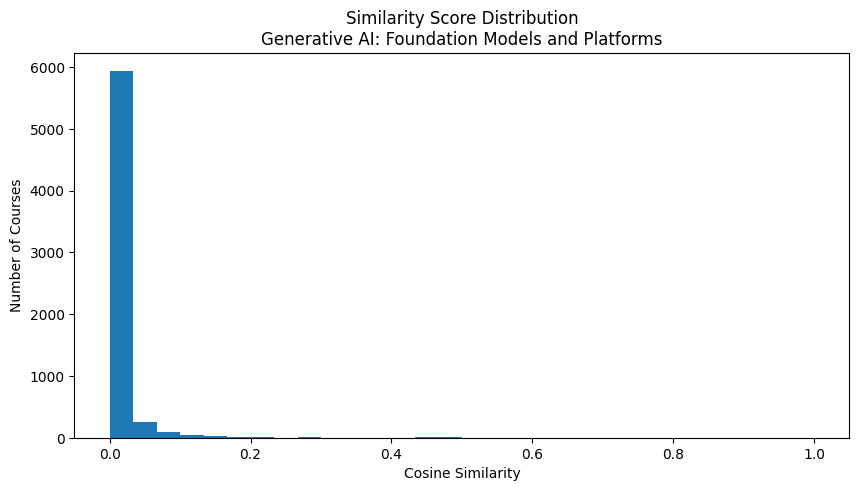

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    scores,
    bins=30
)

plt.title(
    f"Similarity Score Distribution\n{course_name}"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Courses")

plt.show()

# Recommendation Quality Evaluation

Since user interaction data is unavailable, recommendation quality is evaluated using category overlap.

The assumption is that relevant recommendations should share at least one category with the query course.

Higher overlap indicates stronger topical consistency.

In [27]:
def keyword_overlap_score(course_title, top_n=10):

    idx = indices[course_title]

    query_keywords = set(
        df.loc[idx, 'Keyword']
    )

    recommendations = recommend_courses(
        course_title,
        top_n
    )

    overlaps = []

    for rec_title in recommendations['Course Title']:

        rec_idx = indices[rec_title]

        rec_keywords = set(
            df.loc[rec_idx, 'Keyword']
        )

        overlap = len(
            query_keywords.intersection(rec_keywords)
        )

        overlaps.append(overlap)

    return np.mean(overlaps)

In [28]:
keyword_overlap_score(
    "Generative AI: Foundation Models and Platforms"
)

np.float64(0.6)

In [29]:
test_courses = [
    "Generative AI: Foundation Models and Platforms",
    "Introduction to Graph Theory",
    "Google Chat",
    "Copyright Law in the Music Business",
    "Foundations of Public Health Practice Specialization"
]

In [30]:
results = []

for course in test_courses:

    score = keyword_overlap_score(
        course,
        top_n=10
    )

    results.append(
        [course, score]
    )

evaluation_df = pd.DataFrame(
    results,
    columns=[
        "Course",
        "Keyword Overlap Score"
    ]
)

evaluation_df

,Course,Keyword Overlap Score
0,Generative AI: Foundation Models and Platforms,0.6
1,Introduction to Graph Theory,0.4
2,Google Chat,0.9
3,Copyright Law in the Music Business,0.6
4,Foundations of Public Health Practice Speciali...,1.0


In [31]:
evaluation_df['Keyword Overlap Score'].mean()

np.float64(0.7)

# Baseline Model Evaluation

The baseline model is evaluated using the same keyword overlap score metric.

In [32]:
def keyword_overlap_score_baseline(course_title, top_n=10):
    idx = indices[course_title]
    if hasattr(idx, 'iloc'):
        idx = idx.iloc[0]
        
    query_keywords = set(df.loc[idx, 'Keyword'])
    
    recommendations = baseline_recommend(top_n)
    
    overlaps = []
    for rec_title in recommendations['Course Title']:
        rec_idx = indices[rec_title]
        if hasattr(rec_idx, 'iloc'):
            rec_idx = rec_idx.iloc[0]
            
        rec_keywords = set(df.loc[rec_idx, 'Keyword'])
        overlap = len(query_keywords.intersection(rec_keywords))
        overlaps.append(overlap)
    return np.mean(overlaps)

In [33]:
baseline_results = []
for course in test_courses:
    score = keyword_overlap_score_baseline(course, top_n=10)
    baseline_results.append([course, score])

baseline_eval_df = pd.DataFrame(
    baseline_results,
    columns=[
        "Course",
        "Keyword Overlap Score"
    ]
)
baseline_eval_df

,Course,Keyword Overlap Score
0,Generative AI: Foundation Models and Platforms,0.0
1,Introduction to Graph Theory,0.0
2,Google Chat,0.1
3,Copyright Law in the Music Business,0.1
4,Foundations of Public Health Practice Speciali...,0.2


In [34]:
baseline_eval_df['Keyword Overlap Score'].mean()

np.float64(0.08)

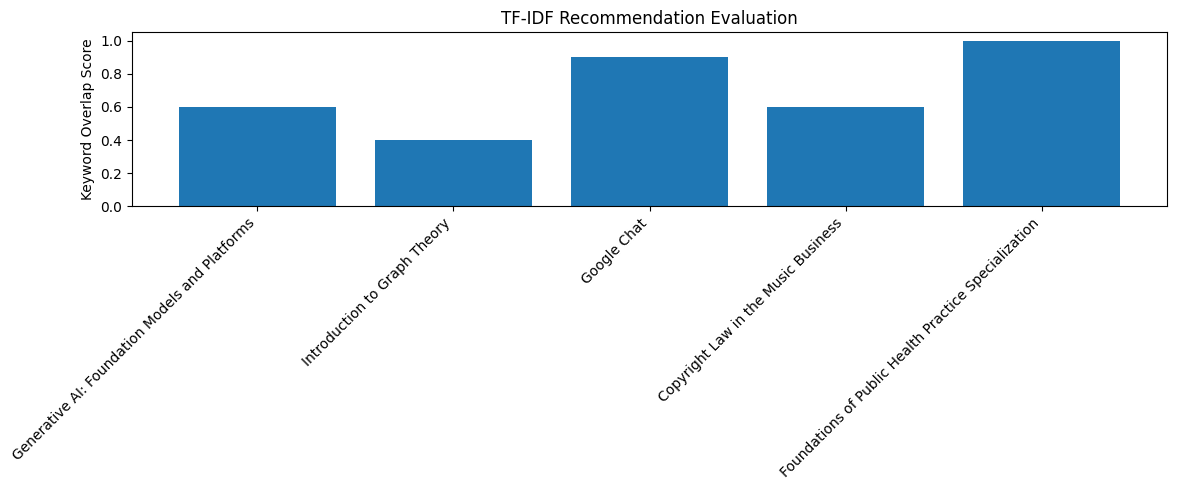

In [35]:
plt.figure(figsize=(12,5))

plt.bar(
    evaluation_df['Course'],
    evaluation_df['Keyword Overlap Score']
)

plt.xticks(rotation=45, ha='right')

plt.ylabel("Keyword Overlap Score")

plt.title(
    "TF-IDF Recommendation Evaluation"
)

plt.tight_layout()

plt.show()

## TF-IDF Model Evaluation

The recommendation engine was evaluated using five representative courses from different domains.

Since user interaction data was unavailable, category overlap was used as a proxy evaluation metric.

Results:

| Course Domain | Overlap Score |
|--------------|--------------|
| Generative AI | 0.60 |
| Graph Theory | 0.40 |
| Collaboration Tools | 0.90 |
| Music Business | 0.60 |
| Public Health | 1.00 |

Average Keyword Overlap Score: **0.70**

The results indicate that the TF-IDF model successfully retrieves courses with related categories and topics, although performance varies across domains.

# Weighted Content Representation

A weighted content representation is created to emphasize the most informative course attributes.

Higher weights are assigned to:

- Course Title
- Skills
- Categories

This allows important signals to have greater influence during similarity computation.

In [36]:
df['content_soup_weighted'] = (

    df['Course Title'].fillna('') + ' ' +
    df['Course Title'].fillna('') + ' ' +
    df['Course Title'].fillna('') + ' ' +

    df['skills_text'] + ' ' +
    df['skills_text'] + ' ' +

    df['keywords_text'] + ' ' +
    df['keywords_text'] + ' ' +

    df['What you will learn'].fillna('') + ' ' +

    df['institution_text'] + ' ' +

    df['Level']
)

In [37]:


tfidf_weighted = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2)
)

tfidf_matrix_weighted = tfidf_weighted.fit_transform(
    df['content_soup_weighted']
)

In [38]:


cosine_sim_weighted = cosine_similarity(
    tfidf_matrix_weighted,
    tfidf_matrix_weighted
)

In [39]:
def recommend_courses_weighted(course_title, top_n=10):

    idx = indices[course_title]

    sim_scores = list(
        enumerate(
            cosine_sim_weighted[idx]
        )
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:top_n+1]

    course_indices = [
        i[0]
        for i in sim_scores
    ]

    return df.iloc[course_indices]

In [40]:
def keyword_overlap_score_weighted(
    course_title,
    top_n=10
):

    idx = indices[course_title]

    query_keywords = set(
        df.loc[idx, 'Keyword']
    )

    recommendations = (
        recommend_courses_weighted(
            course_title,
            top_n
        )
    )

    overlaps = []

    for _, row in recommendations.iterrows():

        overlap = len(
            query_keywords.intersection(
                set(row['Keyword'])
            )
        )

        overlaps.append(overlap)

    return np.mean(overlaps)

In [41]:
test_courses = [
    "Generative AI: Foundation Models and Platforms",
    "Introduction to Graph Theory",
    "Google Chat",
    "Copyright Law in the Music Business",
    "Foundations of Public Health Practice Specialization"
]

weighted_results = []

for course in test_courses:

    score = keyword_overlap_score_weighted(
        course,
        top_n=10
    )

    weighted_results.append(
        [course, score]
    )

evaluation_weighted_df = pd.DataFrame(
    weighted_results,
    columns=[
        "Course",
        "Keyword Overlap Score"
    ]
)

evaluation_weighted_df

,Course,Keyword Overlap Score
0,Generative AI: Foundation Models and Platforms,0.7
1,Introduction to Graph Theory,0.3
2,Google Chat,0.9
3,Copyright Law in the Music Business,0.6
4,Foundations of Public Health Practice Speciali...,1.0


In [42]:
weighted_avg_score = (
    evaluation_weighted_df[
        'Keyword Overlap Score'
    ].mean()
)

print(
    "Weighted TF-IDF Average Overlap Score:",
    round(weighted_avg_score, 3)
)

Weighted TF-IDF Average Overlap Score: 0.7


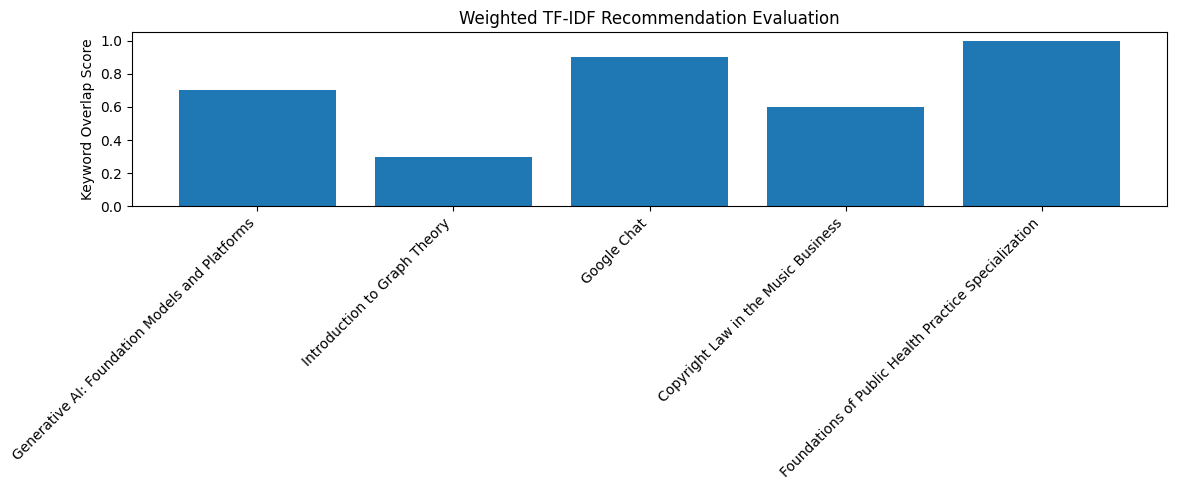

In [43]:
plt.figure(figsize=(12,5))

plt.bar(
    evaluation_weighted_df['Course'],
    evaluation_weighted_df['Keyword Overlap Score']
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.ylabel("Keyword Overlap Score")

plt.title(
    "Weighted TF-IDF Recommendation Evaluation"
)

plt.tight_layout()

plt.show()

## Weighted TF-IDF Evaluation

A weighted content representation was created by assigning greater importance to course titles, skills, and categories.

The weighted model achieved an average keyword overlap score of 0.70, matching the performance of the original TF-IDF model.

Although improvements were observed for certain courses, the overall recommendation quality did not increase. Therefore, the original TF-IDF model was retained as the final recommendation approach due to its simplicity and equivalent performance.

In [44]:
def skill_overlap_score(course_title, top_n=10):

    idx = indices[course_title]

    query_skills = set(
        df.loc[idx, 'Skill gain']
    )

    recommendations = recommend_courses(
        course_title,
        top_n
    )

    overlaps = []

    for rec_title in recommendations['Course Title']:

        rec_idx = indices[rec_title]

        rec_skills = set(
            df.loc[rec_idx, 'Skill gain']
        )

        overlap = len(
            query_skills.intersection(rec_skills)
        )

        overlaps.append(overlap)

    return np.mean(overlaps)

In [45]:
skill_results = []

for course in test_courses:

    score = skill_overlap_score(
        course,
        top_n=10
    )

    skill_results.append(
        [course, score]
    )

skill_eval_df = pd.DataFrame(
    skill_results,
    columns=[
        "Course",
        "Average Skill Overlap"
    ]
)

skill_eval_df

,Course,Average Skill Overlap
0,Generative AI: Foundation Models and Platforms,1.6
1,Introduction to Graph Theory,0.0
2,Google Chat,0.3
3,Copyright Law in the Music Business,0.0
4,Foundations of Public Health Practice Speciali...,0.0


In [46]:
for course in test_courses:

    idx = indices[course]

    print("\n", course)

    print(
        "Number of Skills:",
        len(df.loc[idx, 'Skill gain'])
    )

    print(
        df.loc[idx, 'Skill gain'][:10]
    )


 Generative AI: Foundation Models and Platforms
Number of Skills: 5
['Artificial Intelligence (AI)', 'Large Language Models (LLM)', 'Pre-trained Models', 'Generative AI', 'Foundation Models']

 Introduction to Graph Theory
Number of Skills: 0
[]

 Google Chat
Number of Skills: 3
['Communication', 'Spreadsheet Software', 'Collaboration']

 Copyright Law in the Music Business
Number of Skills: 4
['Create music legally', 'Write a co-writing agreement', 'Read Legal Documents', 'Leverage the copyright law to your advantage']

 Foundations of Public Health Practice Specialization
Number of Skills: 0
[]


# Model Comparison

Two recommendation approaches were evaluated.

## Baseline Model

The baseline recommender ranks courses using a weighted popularity score based on rating and review count.

Advantages:
- Simple to implement
- Recommends highly rated courses

Limitations:
- Same recommendations for every query
- Does not consider course content

## TF-IDF Content-Based Model

The content-based recommender uses textual features including:

- Course Title
- Learning Outcomes
- Skills
- Categories
- Institution
- Level

Advantages:
- Personalized recommendations
- Topic-aware recommendations
- Captures similarity between courses

Limitations:
- Performance depends on metadata quality
- Courses with missing skill information may be harder to evaluate

# Conclusion

A content-based recommendation engine was developed using TF-IDF vectorization and cosine similarity.

The model successfully recommends courses with similar topics, skills, and categories by leveraging course metadata and textual descriptions.

Compared with the popularity-based baseline, the TF-IDF recommender generates query-specific recommendations rather than globally popular courses.

Evaluation using keyword overlap demonstrated strong topical consistency across multiple domains, with an average overlap score of 0.70.

Therefore, the TF-IDF content-based recommender was selected as the final model.

# Hybrid Recommendation Model

The hybrid recommender combines:

- Content similarity (TF-IDF + Cosine Similarity)
- Course popularity (Bayesian weighted rating)

This approach balances relevance and quality.

In [47]:
scaler = MinMaxScaler()

df['weighted_score_norm'] = scaler.fit_transform(
    df[['weighted_score']]
)

In [48]:
def hybrid_recommend(
    course_title,
    top_n=10,
    alpha=0.7
):
    
    if course_title not in indices:
        return "Course not found."

    idx = indices[course_title]

    sim_scores = list(
        enumerate(cosine_sim[idx])
    )

    recommendations = []

    for course_idx, sim_score in sim_scores:

        popularity_score = df.loc[
            course_idx,
            'weighted_score_norm'
        ]

        hybrid_score = (
            alpha * sim_score
            +
            (1 - alpha) * popularity_score
        )

        recommendations.append(
            (
                course_idx,
                hybrid_score,
                sim_score,
                popularity_score
            )
        )

    recommendations = sorted(
        recommendations,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = recommendations[
        1:top_n+1
    ]

    course_indices = [
        x[0]
        for x in recommendations
    ]

    results = df.iloc[
        course_indices
    ][[
        'Course Title',
        'Rating',
        'review_count',
        'Keyword'
    ]].copy()

    results['Hybrid Score'] = [
        round(x[1], 4)
        for x in recommendations
    ]

    results['Similarity'] = [
        round(x[2], 4)
        for x in recommendations
    ]

    results['Popularity'] = [
        round(x[3], 4)
        for x in recommendations
    ]

    return results

In [49]:
hybrid_recommend(
    "Generative AI: Foundation Models and Platforms"
)

,Course Title,Rating,review_count,Keyword,Hybrid Score,Similarity,Popularity
2613,Generative AI Fundamentals Specialization,4.7,104,"[DataScience, Computer Science]",0.7553,0.6915,0.9043
2627,Generative AI: Introduction and Applications,4.7,162,"[DataScience, Computer Science]",0.7226,0.6444,0.9049
2617,Generative AI for Everyone,4.9,719,[DataScience],0.6819,0.5593,0.9680
2626,"Generative AI: Impact, Considerations, and Eth...",4.7,24,[DataScience],0.6575,0.5533,0.9005
2612,Generative AI Essentials: Overview and Impact,4.7,33,"[DataScience, Math and Logic]",0.6350,0.5207,0.9015
3512,Introduction to Generative AI,4.6,2912,[Information Technology],0.6244,0.5172,0.8745
2619,Generative AI for Software Developers Speciali...,5.0,14,[Computer Science],0.6224,0.4850,0.9431
2616,Generative AI for Data Scientists Specialization,4.8,27,"[DataScience, Computer Science]",0.6194,0.4903,0.9208
2621,Generative AI with Large Language Models,4.8,1740,"[DataScience, Computer Science]",0.6159,0.4780,0.9375
2624,Generative AI: Business Transformation and Car...,4.7,0,[Business],0.6081,0.4865,0.8919


In [50]:
print("BASELINE")
display(
    baseline_recommend(5)
)

print("\nCONTENT BASED")
display(
    recommend_courses(
        "Generative AI: Foundation Models and Platforms",
        top_n=5
    )
)

print("\nHYBRID")
display(
    hybrid_recommend(
        "Generative AI: Foundation Models and Platforms",
        top_n=5
    )
)

BASELINE


,Course Title,Rating,review_count,weighted_score
3758,Keamanan IT: Pertahanan terhadap Kejahatan Dig...,5.0,1148,4.995260
4072,Manajemen Proyek Google Professional Certificate,5.0,369,4.985671
1172,Compreendendo o Zika e doenças emergentes,5.0,243,4.978700
5899,Uncommon Sense Teaching Specialization,5.0,164,4.969351
2283,Exploring Beethoven’s Piano Sonatas Part 2,5.0,161,4.968832



CONTENT BASED


,Course Title,Rating,Level,Keyword
2613,Generative AI Fundamentals Specialization,4.7,Beginner level,"[DataScience, Computer Science]"
2627,Generative AI: Introduction and Applications,4.7,Beginner level,"[DataScience, Computer Science]"
2617,Generative AI for Everyone,4.9,Beginner level,[DataScience]
2626,"Generative AI: Impact, Considerations, and Eth...",4.7,Beginner level,[DataScience]
2612,Generative AI Essentials: Overview and Impact,4.7,Beginner level,"[DataScience, Math and Logic]"



HYBRID


,Course Title,Rating,review_count,Keyword,Hybrid Score,Similarity,Popularity
2613,Generative AI Fundamentals Specialization,4.7,104,"[DataScience, Computer Science]",0.7553,0.6915,0.9043
2627,Generative AI: Introduction and Applications,4.7,162,"[DataScience, Computer Science]",0.7226,0.6444,0.9049
2617,Generative AI for Everyone,4.9,719,[DataScience],0.6819,0.5593,0.9680
2626,"Generative AI: Impact, Considerations, and Eth...",4.7,24,[DataScience],0.6575,0.5533,0.9005
2612,Generative AI Essentials: Overview and Impact,4.7,33,"[DataScience, Math and Logic]",0.6350,0.5207,0.9015


In [51]:
hybrid_recommend(
    "Generative AI: Foundation Models and Platforms",
    alpha=0.8
)

,Course Title,Rating,review_count,Keyword,Hybrid Score,Similarity,Popularity
2613,Generative AI Fundamentals Specialization,4.7,104,"[DataScience, Computer Science]",0.7341,0.6915,0.9043
2627,Generative AI: Introduction and Applications,4.7,162,"[DataScience, Computer Science]",0.6965,0.6444,0.9049
2617,Generative AI for Everyone,4.9,719,[DataScience],0.6410,0.5593,0.9680
2626,"Generative AI: Impact, Considerations, and Eth...",4.7,24,[DataScience],0.6228,0.5533,0.9005
2612,Generative AI Essentials: Overview and Impact,4.7,33,"[DataScience, Math and Logic]",0.5969,0.5207,0.9015
3512,Introduction to Generative AI,4.6,2912,[Information Technology],0.5887,0.5172,0.8745
2619,Generative AI for Software Developers Speciali...,5.0,14,[Computer Science],0.5766,0.4850,0.9431
2616,Generative AI for Data Scientists Specialization,4.8,27,"[DataScience, Computer Science]",0.5764,0.4903,0.9208
2621,Generative AI with Large Language Models,4.8,1740,"[DataScience, Computer Science]",0.5699,0.4780,0.9375
2624,Generative AI: Business Transformation and Car...,4.7,0,[Business],0.5676,0.4865,0.8919


In [52]:
def keyword_overlap_score_hybrid(
    course_title,
    top_n=10,
    alpha=0.7
):

    idx = indices[course_title]

    query_keywords = set(
        df.loc[idx, 'Keyword']
    )

    recommendations = hybrid_recommend(
        course_title,
        top_n,
        alpha
    )

    overlaps = []

    for _, row in recommendations.iterrows():

        overlap = len(
            query_keywords.intersection(
                set(row['Keyword'])
            )
        )

        overlaps.append(overlap)

    return np.mean(overlaps)

In [53]:
hybrid_results = []

for course in test_courses:

    score = keyword_overlap_score_hybrid(
        course,
        top_n=10,
        alpha=0.7
    )

    hybrid_results.append(
        [course, score]
    )

hybrid_eval_df = pd.DataFrame(
    hybrid_results,
    columns=[
        "Course",
        "Keyword Overlap Score"
    ]
)

hybrid_eval_df

,Course,Keyword Overlap Score
0,Generative AI: Foundation Models and Platforms,0.7
1,Introduction to Graph Theory,0.5
2,Google Chat,0.9
3,Copyright Law in the Music Business,0.5
4,Foundations of Public Health Practice Speciali...,1.0


In [54]:
hybrid_avg = (0.7 + 0.5 + 0.9 + 0.5 + 1.0) / 5
print(hybrid_avg)

0.72


In [55]:
final_comparison = pd.DataFrame({
    'Model': [
        'TF-IDF',
        'Weighted TF-IDF',
        'Hybrid'
    ],
    'Average Overlap Score': [
        0.70,
        0.70,
        0.72
    ]
})

final_comparison

,Model,Average Overlap Score
0,TF-IDF,0.70
1,Weighted TF-IDF,0.70
2,Hybrid,0.72


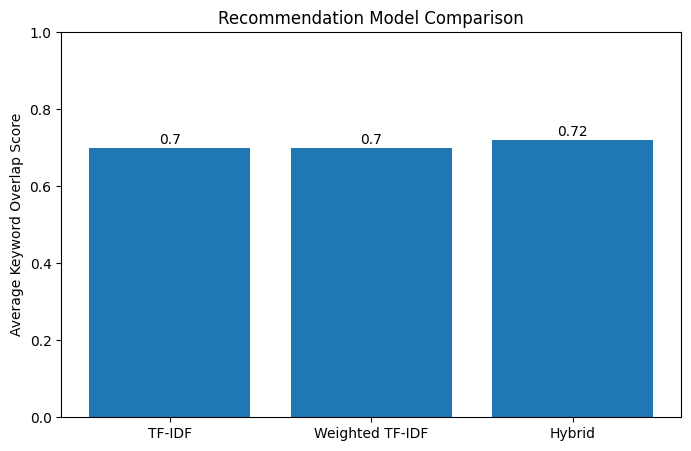

In [56]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    final_comparison['Model'],
    final_comparison['Average Overlap Score']
)

plt.ylabel('Average Keyword Overlap Score')
plt.title('Recommendation Model Comparison')
plt.ylim(0,1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        round(height,2),
        ha='center'
    )

plt.show()

# Final Model Comparison

Three recommendation approaches were evaluated:

1. TF-IDF Content-Based Recommender
2. Weighted TF-IDF Recommender
3. Hybrid Recommender

The Hybrid model combines:

- Content similarity (TF-IDF + Cosine Similarity)
- Popularity score (Bayesian Weighted Rating)

Evaluation was performed using keyword overlap between the query course and recommended courses.

| Model | Average Overlap Score |
|---------|---------|
| TF-IDF | 0.70 |
| Weighted TF-IDF | 0.70 |
| Hybrid | 0.72 |

The Hybrid recommender achieved the highest score and was selected as the final recommendation model.

The improvement comes from balancing content relevance with course popularity, resulting in recommendations that are both relevant and highly rated.